# 第 11 章 · TD(0) 代码实验

[章节网页](../ch11.html)

## 运行内容

- 运行 Sutton random walk
- 输出 TD target
- 绘制状态价值

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# Sutton random walk：A-B-C-D-E 五个非终止状态，右端奖励为 1。
rw_states = ["A", "B", "C", "D", "E"]
V_td = defaultdict(lambda: 0.5)
V_td["L"] = 0.0
V_td["R"] = 0.0
alpha = 0.4
gamma = 1.0
episodes = [
    ["C", "D", "E", "R"],
    ["C", "B", "A", "L"],
    ["C", "D", "C", "D", "E", "R"],
]
td_rows = []

step = 0
for episode_id, episode in enumerate(episodes, start=1):
    for state, next_state in zip(episode, episode[1:]):
        if state in {"L", "R"}:
            continue
        step += 1
        reward = 1.0 if next_state == "R" else 0.0
        target = reward + gamma * V_td[next_state]
        old = V_td[state]
        V_td[state] = old + alpha * (target - old)
        td_rows.append({
            "episode": episode_id,
            "步": step,
            "状态": state,
            "下一状态": next_state,
            "TD target": round(target, 3),
            "更新后V": round(V_td[state], 3),
        })

td_trace = pd.DataFrame(td_rows)
display(td_trace)

,episode,步,状态,下一状态,TD target,更新后V
0,1,1,C,D,0.5,0.50
1,1,2,D,E,0.5,0.50
2,1,3,E,R,1.0,0.70
3,2,4,C,B,0.5,0.50
4,2,5,B,A,0.5,0.50
5,2,6,A,L,0.0,0.30
6,3,7,C,D,0.5,0.50
7,3,8,D,C,0.5,0.50
8,3,9,C,D,0.5,0.50
9,3,10,D,E,0.7,0.58


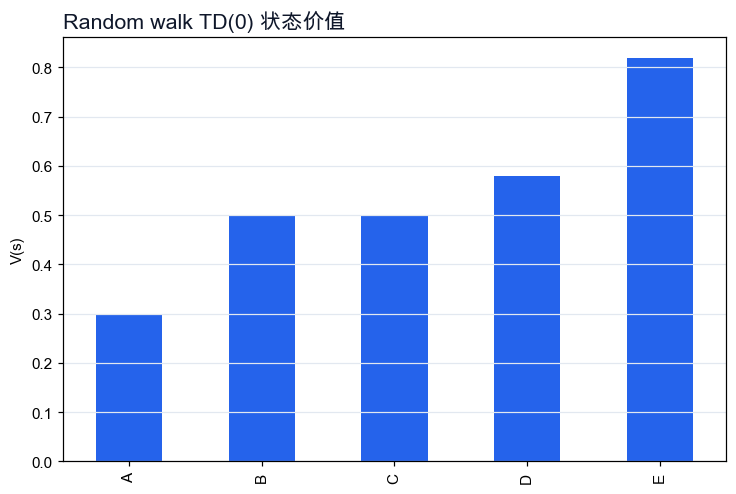

In [3]:
# 绘制 TD 更新后的状态价值。
fig, ax = plt.subplots(figsize=(6.8, 4.6))
td_values = pd.Series({state: V_td[state] for state in rw_states})
td_values.plot(kind="bar", ax=ax, color="#2563eb")
ax.set_title("Random walk TD(0) 状态价值", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
ax.set_ylabel("V(s)")
ax.grid(True, axis="y", color="#e2e8f0", linewidth=0.8)
plt.tight_layout()
plt.show()